Minimum people needed: 10
Collision probability: 0.11694817771107757


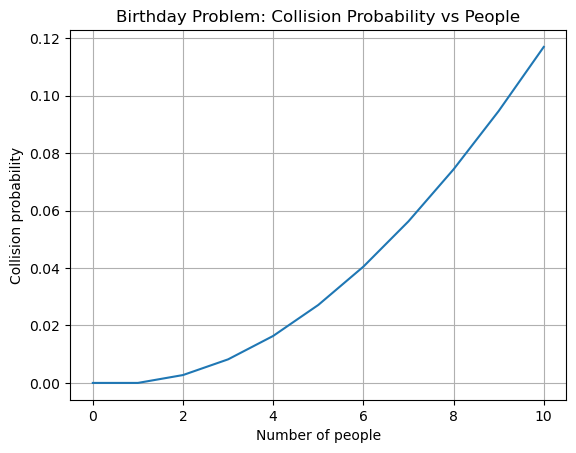

In [1]:
# The Birthday Problem
# Classic Problem for showing the counter intuitive nature of Probability.

# The Problem Aims to calculate the likelihood of two people having same birthday in a room of k people.
# Assuming 1.)The birthdays of people are independent of each other.
#          2.)There is a uniform distribution of birthdays.
#          3.)The Naive definition of probability is applicable.

# Approach:- 1.)Analytical(Exact): Calculate the exact probability that at least two people share a birthday among 'n' people(assume D possible days, typically 365)
#            2.)Simulation(Monte carlo): Simulate many random groups of 'n' people and estimate the fraction that contains a collision.

# Approach 1

# Defining the generic factorial
def factorial(k):
    f = 1
    while k>0:
        f*=k
        k-=1
    return f

# Defining the falling factorial
def falling_factorial(D, n):
    return factorial(D)/factorial(D-n)

# Calculating the probability threshold 
# Minimum value of n where P(>=2) == 0.5
D = 365

people = []
collision_probs = []

for i in range(0,D+1):
    distinct_birthdays_probability = falling_factorial(D,i)/D**i
    collision_probability = 1 - distinct_birthdays_probability

    people.append(i)
    collision_probs.append(collision_probability)
    
    if collision_probability>=0.1:
        print("Minimum people needed:", i)
        print("Collision probability:", collision_probability)
        break

def plot_collision_probability(people, collision_probs):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.plot(people, collision_probs)
    plt.xlabel("Number of people")
    plt.ylabel("Collision probability")
    plt.title("Birthday Problem: Collision Probability vs People")
    plt.grid(True)
    plt.show()

plot_collision_probability(people, collision_probs)

(41, 0.9052)


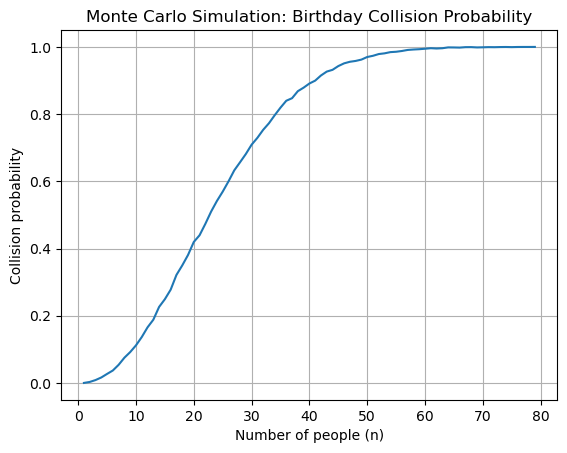

In [1]:
# Approach 2: Monte Carlo Simulation
# Core idea: repeat a simple random experiment many times and estimate the probabilities from the frequencies

import random
import matplotlib.pyplot as plt

def has_birthday_collision(n, days = 365):
    seen = set()
    for _ in range(n):
        day = random.randint(1,days)
        if day in seen:
            return True
        seen.add(day)
    return False

def monte_carlo_birthday_prob(n, trails = 10000,days = 365):
    collision_count = 0
    
    for _ in range(trails):
        if has_birthday_collision(n,days):
            collision_count += 1

    return collision_count/trails

def find_threshold(target,trails):
    n=1
    while True:
        p = monte_carlo_birthday_prob(n,trails)
        if p >= target:
            return n,p
        n+=1

print(find_threshold(0.9,10000))

def plot_the_probability_curve(target, trails = 10000, days = 365):

    people = []
    collision_probs = []

    n=1
    while True:
        p = monte_carlo_birthday_prob(n,trails,days)
        
        people.append(n)
        collision_probs.append(p)
        
        if p >= target:  
            break
        
        n+=1

    plt.figure()
    plt.plot(people, collision_probs)
    plt.xlabel("Number of people (n)")
    plt.ylabel("Collision probability")
    plt.title("Monte Carlo Simulation: Birthday Collision Probability")
    plt.grid(True)
    plt.show()

threshold_n, threshold_p = find_threshold(1, 10000)
plot_the_probability_curve(threshold_p, 10000)